# Vietnamese VQA Training Notebook
This notebook trains four VQA model variants and saves checkpoints to `/kaggle/working`.

## Install Dependencies
Install missing Python packages for Kaggle.

In [1]:
# Install extra dependencies (Kaggle kernel may not include these)
!pip -q install underthesea nltk pyyaml


## Setup Paths
Configure project root and working directory.

In [2]:
import os
import sys

PROJECT_ROOT = '/kaggle/input/datasets/nguynanhphm/midterm-dl-2/vqa-vietnamese'
if not os.path.exists(PROJECT_ROOT):
    PROJECT_ROOT = os.getcwd()

WORK_DIR = '/kaggle/working'
os.makedirs(f'{WORK_DIR}/checkpoints', exist_ok=True)

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('WORK_DIR:', WORK_DIR)


PROJECT_ROOT: /kaggle/input/datasets/nguynanhphm/midterm-dl-2/vqa-vietnamese
WORK_DIR: /kaggle/working


## Imports and Config
Load modules and override dataset/checkpoint paths for Kaggle.

In [3]:
import yaml
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from data.preprocessing import build_vocab_from_json, load_fasttext_embeddings
from utils.vocabulary import Vocabulary
from data.dataloader import build_dataloaders
from models.cnn_encoder import CNNEncoder
from models.resnet_encoder import ResNet50Encoder
from models.question_encoder import QuestionEncoder
from models.attention import BahdanauAttention
from models.fusion import FusionModule
from models.decoder import LSTMDecoder
from models.vqa_model import VQAModel
from training.loss import get_loss_fn
from training.trainer import Trainer, set_seed

with open(f'{PROJECT_ROOT}/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Override paths for Kaggle
config['data']['train_json'] = f'{PROJECT_ROOT}/dataset/openvivqa_train_v2.json'
config['data']['dev_json'] = f'{PROJECT_ROOT}/dataset/openvivqa_dev_v2.json'
config['data']['test_json'] = f'{PROJECT_ROOT}/dataset/openvivqa_test_v2.json'
config['data']['images_dir'] = f'{PROJECT_ROOT}/dataset/images'
config['data']['embeddings_path'] = f'{PROJECT_ROOT}/embeddings/cc.vi.300.vec'
config['data']['vocab_path'] = f'{WORK_DIR}/vocab.json'

config['checkpoints']['cnn_baseline'] = f'{WORK_DIR}/checkpoints/cnn_baseline.pth'
config['checkpoints']['cnn_attention'] = f'{WORK_DIR}/checkpoints/cnn_attention.pth'
config['checkpoints']['resnet_baseline'] = f'{WORK_DIR}/checkpoints/resnet_baseline.pth'
config['checkpoints']['resnet_attention'] = f'{WORK_DIR}/checkpoints/resnet_attention.pth'


## Training Configuration
Override training hyperparameters for this run.

In [4]:
# Training overrides (edit here)
TRAIN_OVERRIDES = {
    'num_epochs': 20,
    'batch_size': 192,
    'learning_rate': 1e-4,
    'weight_decay': 0.0,
    'teacher_forcing_ratio': 0.5,
    'teacher_forcing_min': 0.1,
    'teacher_forcing_decay': 0.02,
    'num_workers': 4,
    'use_amp': True,
    'prefetch_factor': 4,
}
config['training'].update(TRAIN_OVERRIDES)

# Resume from latest checkpoint if available
RESUME_FROM_LATEST = True

set_seed(config['training']['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## Vocabulary and Embeddings
Build or load vocabulary and initialize FastText embeddings.

In [5]:
vocab_path = config['data']['vocab_path']
if os.path.exists(vocab_path):
    vocab = Vocabulary.from_json(vocab_path)
else:
    vocab = build_vocab_from_json([
        config['data']['train_json'],
        config['data']['dev_json'],
        config['data']['test_json'],
    ], max_size=config['data']['vocab_size'])
    os.makedirs(os.path.dirname(vocab_path), exist_ok=True)
    vocab.to_json(vocab_path)

embeddings = load_fasttext_embeddings(
    config['data']['embeddings_path'],
    vocab,
    embedding_dim=config['model']['embedding_dim']
)


## Build DataLoaders
Create train/val/test data loaders.

In [6]:
train_loader, val_loader, test_loader = build_dataloaders(config, vocab)


## Dataset Statistics
Print dataset sizes and basic sanity checks.

In [7]:
# Dataset statistics and sanity checks
from data.preprocessing import load_dataset, parse_annotations

def dataset_stats(json_path):
    data = load_dataset(json_path)
    images = len(data.get('images', []))
    annotations = len(data.get('annotations', []))
    samples = parse_annotations(data)
    return images, annotations, len(samples)

for split_name, split_path in [
    ('train', config['data']['train_json']),
    ('dev', config['data']['dev_json']),
    ('test', config['data']['test_json']),
]:
    img_count, ann_count, sample_count = dataset_stats(split_path)
    print(f'{split_name}: images={img_count}, annotations={ann_count}, samples={sample_count}')

print('Images directory exists:', os.path.exists(config['data']['images_dir']))
if os.path.exists(config['data']['images_dir']):
    print('Images directory:', config['data']['images_dir'])


train: images=9129, annotations=30833, samples=30833
dev: images=1070, annotations=3545, samples=3545
test: images=1000, annotations=3536, samples=3536
Images directory exists: True
Images directory: /kaggle/input/datasets/nguynanhphm/midterm-dl-2/vqa-vietnamese/dataset/images


## Model Factory
Define the model constructor for each variant.

In [8]:
def build_model(variant: str):
    use_attention = 'attention' in variant
    use_resnet = 'resnet' in variant

    if use_resnet:
        image_encoder = ResNet50Encoder(pretrained=True)
        image_dim = config['model']['resnet_out_dim']
    else:
        image_encoder = CNNEncoder(out_dim=config['model']['cnn_out_dim'])
        image_dim = config['model']['cnn_out_dim']

    question_encoder = QuestionEncoder(
        vocab_size=len(vocab),
        embedding_dim=config['model']['embedding_dim'],
        hidden_size=config['model']['question_hidden_size'],
        padding_idx=vocab.pad_idx,
        embeddings=embeddings,
    )

    attention = BahdanauAttention(
        image_dim=image_dim,
        hidden_dim=config['model']['decoder_hidden_size'],
        attn_dim=config['model']['attention_dim'],
    ) if use_attention else None

    fusion = FusionModule(
        image_dim=image_dim,
        question_dim=config['model']['question_hidden_size'],
        hidden_dim=config['model']['decoder_hidden_size'],
    )

    decoder = LSTMDecoder(
        vocab_size=len(vocab),
        embedding_dim=config['model']['embedding_dim'],
        hidden_dim=config['model']['decoder_hidden_size'],
        image_dim=image_dim,
        padding_idx=vocab.pad_idx,
        attention=attention,
        embeddings=embeddings,
    )

    model = VQAModel(image_encoder, question_encoder, fusion, decoder, use_attention=use_attention)
    return model


## Training Loop
Train each variant and save checkpoints.

In [9]:
def train_variant(variant: str, checkpoint_path: str):
    model = build_model(variant).to(device)

    if 'resnet' in variant:
        model.image_encoder.freeze_backbone()
        stage1_epochs = max(1, config['training']['num_epochs'] // 2)
    else:
        stage1_epochs = config['training']['num_epochs']

    optimizer = Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['training']['learning_rate'],
        weight_decay=config['training']['weight_decay'],
    )
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    loss_fn = get_loss_fn(vocab.pad_idx)

    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_fn=loss_fn,
        vocab=vocab,
        device=device,
        use_amp=config['training']['use_amp'],
    )

    latest_path_stage1 = checkpoint_path.replace('.pth', '_latest_stage1.pth')
    resume_path_stage1 = latest_path_stage1 if RESUME_FROM_LATEST else None

    # STAGE 1
    trainer.train(
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=stage1_epochs, # Uses 10 for ResNet, 20 for non-ResNet
        teacher_forcing_ratio=config['training']['teacher_forcing_ratio'],
        teacher_forcing_min=config['training']['teacher_forcing_min'],
        teacher_forcing_decay=config['training']['teacher_forcing_decay'],
        grad_clip=config['training']['grad_clip'],
        beam_width=config['inference']['beam_width'],
        max_len=config['inference']['max_answer_len'],
        checkpoint_path=checkpoint_path,
        resume_path=resume_path_stage1,
        latest_path=latest_path_stage1,
    )

    # STAGE 2 (RESNET ONLY)
    if 'resnet' in variant:
        model.image_encoder.unfreeze_last_block()
        
        # Re-initialize optimizer and scheduler for fine-tuning
        optimizer = Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config['training']['learning_rate'],
            weight_decay=config['training']['weight_decay'],
        )
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        
        trainer = Trainer(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            loss_fn=loss_fn,
            vocab=vocab,
            device=device,
            use_amp=config['training']['use_amp'],
        )
        
        latest_path_stage2 = checkpoint_path.replace('.pth', '_latest_stage2.pth')
        resume_path_stage2 = latest_path_stage2 if RESUME_FROM_LATEST else None
        
        stage2_epochs = config['training']['num_epochs'] - stage1_epochs
        
        trainer.train(
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=max(1, stage2_epochs),
            teacher_forcing_ratio=config['training']['teacher_forcing_ratio'],
            teacher_forcing_min=config['training']['teacher_forcing_min'],
            teacher_forcing_decay=config['training']['teacher_forcing_decay'],
            grad_clip=config['training']['grad_clip'],
            beam_width=config['inference']['beam_width'],
            max_len=config['inference']['max_answer_len'],
            checkpoint_path=checkpoint_path,
            resume_path=resume_path_stage2,
            latest_path=latest_path_stage2,
        )

    return model

In [10]:
variants = {
    'cnn_baseline': config['checkpoints']['cnn_baseline'],
    'cnn_attention': config['checkpoints']['cnn_attention'],
    'resnet_baseline': config['checkpoints']['resnet_baseline'],
    'resnet_attention': config['checkpoints']['resnet_attention'],
}

trained_models = {}
for variant, ckpt in variants.items():
    print(f'Training {variant}')
    trained_models[variant] = train_variant(variant, ckpt)


Training cnn_baseline


/kaggle/input/datasets/nguynanhphm/midterm-dl-2/vqa-vietnamese/training/trainer.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=use_amp)


Resuming from checkpoint: /kaggle/working/checkpoints/cnn_baseline_latest_stage1.pth
Resumed at epoch 11 with best BLEU-4 0.0003


Training:   0%|          | 0/161 [00:00<?, ?it/s]/kaggle/input/datasets/nguynanhphm/midterm-dl-2/vqa-vietnamese/training/trainer.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


Epoch 11/20
Training loss: 5.3982
Validation loss: 5.8263
BLEU-1: 0.0012 | BLEU-4: 0.0000 | ROUGE-L: 0.0433 | METEOR: 0.0000 | Exact Match: 0.0000


...

Epoch 6/10
Training loss: 3.9625
Validation loss: 5.3620
BLEU-1: 0.0875 | BLEU-4: 0.0164 | ROUGE-L: 0.1599 | METEOR: 0.0000 | Exact Match: 0.0104
Saved checkpoint to /kaggle/working/checkpoints/resnet_attention.pth


Epoch 7/10
Training loss: 3.8426
Validation loss: 5.3657
BLEU-1: 0.0802 | BLEU-4: 0.0161 | ROUGE-L: 0.1580 | METEOR: 0.0000 | Exact Match: 0.0113


Epoch 8/10
Training loss: 3.7228
Validation loss: 5.3633
BLEU-1: 0.1008 | BLEU-4: 0.0216 | ROUGE-L: 0.1676 | METEOR: 0.0000 | Exact Match: 0.0099
Saved checkpoint to /kaggle/working/checkpoints/resnet_attention.pth


Epoch 9/10
Training loss: 3.6096
Validation loss: 5.3672
BLEU-1: 0.1109 | BLEU-4: 0.0222 | ROUGE-L: 0.1763 | METEOR: 0.0000 | Exact Match: 0.0116
Saved checkpoint to /kaggle/working/checkpoints/resnet_attention.pth


Epoch 10/10
Training loss: 3.4827
Validation loss: 5.4026
BLEU-1: 0.1001 | BLEU-4: 0.0210 | ROUGE-L: 0.1747 | METEOR: 0.0000 | Exact Match: 0.0113


## Evaluation and Comparison
Evaluate all checkpoints on validation and test splits and compare metrics.

{
  "cnn_baseline": {
    "val_loss": 5.57384739424053,
    "test_loss": 5.5619727937798755,
    "val_metrics": {
      "bleu1": 0.033510776504906,
      "bleu4": 0.007774669183563758,
      "rouge_l": 0.08468025818942337,
      "meteor": 0.0,
      "exact_match": 0.0031029619181946405
    },
    "test_metrics": {
      "bleu1": 0.040920434024187276,
      "bleu4": 0.011550640292531483,
      "rouge_l": 0.09488435206348401,
      "meteor": 0.0,
      "exact_match": 0.0022624434389140274
    }
  },
  "cnn_attention": {
    "val_loss": 5.5640558443571395,
    "test_loss": 5.557980160964163,
    "val_metrics": {
      "bleu1": 0.01796090447509943,
      "bleu4": 0.002346473244649516,
      "rouge_l": 0.08728550722004064,
      "meteor": 0.0,
      "exact_match": 0.005359661495063469
    },
    "test_metrics": {
      "bleu1": 0.01918958587940286,
      "bleu4": 0.002462605369365267,
      "rouge_l": 0.087508432625822,
      "meteor": 0.0,
      "exact_match": 0.004807692307692308
    }
  

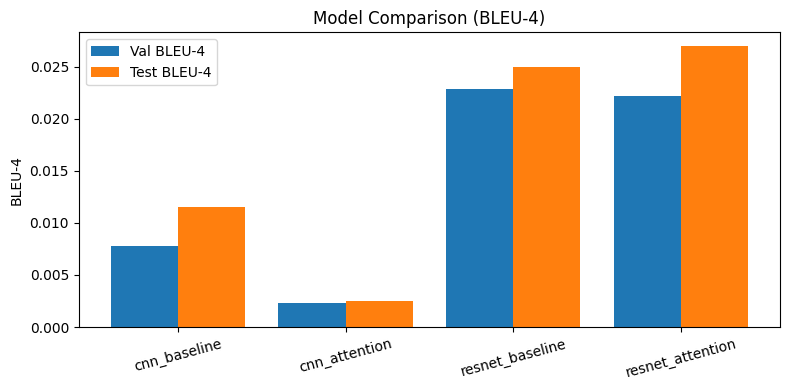

In [11]:
# Evaluation and comparison
import json
import matplotlib.pyplot as plt

def load_model_weights(model, ckpt_path, device):
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and 'model_state' in state:
        state = state['model_state']
    model.load_state_dict(state)
    return model

loss_fn = get_loss_fn(vocab.pad_idx)
results = {}
eval_models = {}
for variant, ckpt in variants.items():
    model = build_model(variant).to(device)
    model = load_model_weights(model, ckpt, device)
    model.eval()
    eval_models[variant] = model
    trainer = Trainer(
        model=model,
        optimizer=None,
        scheduler=None,
        loss_fn=loss_fn,
        vocab=vocab,
        device=device,
        use_amp=False,
    )
    val_loss, val_metrics = trainer.evaluate(val_loader, beam_width=config['inference']['beam_width'], max_len=config['inference']['max_answer_len'])
    test_loss, test_metrics = trainer.evaluate(test_loader, beam_width=config['inference']['beam_width'], max_len=config['inference']['max_answer_len'])
    results[variant] = {
        'val_loss': val_loss,
        'test_loss': test_loss,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
    }

print(json.dumps(results, indent=2))

# Visualization: compare BLEU-4 on validation and test
labels = list(results.keys())
val_bleu4 = [results[k]['val_metrics']['bleu4'] for k in labels]
test_bleu4 = [results[k]['test_metrics']['bleu4'] for k in labels]

x = range(len(labels))
plt.figure(figsize=(8, 4))
plt.bar([i - 0.2 for i in x], val_bleu4, width=0.4, label='Val BLEU-4')
plt.bar([i + 0.2 for i in x], test_bleu4, width=0.4, label='Test BLEU-4')
plt.xticks(list(x), labels, rotation=15)
plt.ylabel('BLEU-4')
plt.title('Model Comparison (BLEU-4)')
plt.legend()
plt.tight_layout()
plt.show()


## Qualitative Examples
Inspect model predictions for a few validation samples.

In [12]:
# Qualitative comparison on a few samples
def decode_question(q_ids):
    return ' '.join(vocab.decode(q_ids, stop_at_end=False))

def decode_answer(a_ids):
    return ' '.join(vocab.decode(a_ids, stop_at_end=True))

sample_count = 3
shown = 0

for images, questions, answers_input, answers_target in val_loader:
    batch_size = images.size(0)
    for i in range(batch_size):
        q_text = decode_question(questions[i].cpu().tolist())
        a_text = decode_answer(answers_target[i].cpu().tolist())
        print('Question:', q_text)
        print('Ground Truth:', a_text)

        img = images[i:i+1].to(device)
        ques = questions[i:i+1].to(device)
        for variant, model in eval_models.items():
            model.eval()
            with torch.no_grad():
                seq = model.generate(
                    img,
                    ques,
                    start_idx=vocab.start_idx,
                    end_idx=vocab.end_idx,
                    beam_width=config['inference']['beam_width'],
                    max_len=config['inference']['max_answer_len'],
                )[0]
            pred = decode_answer(seq)
            print(f'{variant}:', pred)
        print('-' * 60)
        shown += 1
        if shown >= sample_count:
            break
    if shown >= sample_count:
        break


Question: người dân không được tụ tập quá bao nhiêu người ?
Ground Truth: 10 người
cnn_baseline: cửa hàng
cnn_attention: có
resnet_baseline: có hai người
resnet_attention: khu vực này này đang trong trong
------------------------------------------------------------
Question: chợ này ở phường nào ?
Ground Truth: thanh xuân trung
cnn_baseline: cửa hàng
cnn_attention: đây
resnet_baseline: <UNK>
resnet_attention: khu vực này này này
------------------------------------------------------------
Question: đây đang ở chợ gì ?
Ground Truth: chợ <UNK>
cnn_baseline: màu đỏ
cnn_attention: có
resnet_baseline: đây là <UNK>
resnet_attention: khu vực này này này
------------------------------------------------------------
